# CodeAlpha - Task 1
# Credit Scoring Model

### Objective
Predict the credit risk of customers using their financial and credit history.

### Machine Learning Models
1. Logistic Regression
2. Decision Tree
3. Random Forest

### Evaluation Metrics
- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
from google.colab import files

uploaded = files.upload()

Saving CodeAlpha_Credit_Scoring_Dataset.csv to CodeAlpha_Credit_Scoring_Dataset.csv


In [3]:
df = pd.read_csv("CodeAlpha_Credit_Scoring_Dataset.csv")

df.head()

,age,employment_status,annual_income,avg_monthly_balance,num_deposits_per_month,debit_card_spending,credit_score,num_open_loans,total_outstanding_debt,late_payment_count,loan_default_history,loan_application_amount,loan_repayment_history,debt_to_income_ratio,credit_risk
0,59,Employed,86331.0,4607.0,1,2092,685.0,2,41960.0,1,0,21050,Poor,0.486,1
1,49,Employed,49394.0,2072.0,5,2169,741.0,2,21647.0,2,0,17330,Good,0.438,0
2,35,Employed,64768.0,4341.0,1,3102,550.0,1,20315.0,1,0,14284,Excellent,0.314,0
3,63,Employed,137596.0,8105.0,3,5904,686.0,2,53287.0,0,0,28094,Good,0.387,0
4,28,Employed,17101.0,296.0,1,306,675.0,2,9797.0,0,0,5919,Average,0.573,0


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 5000
Number of columns: 15


In [5]:
df.head(10)

,age,employment_status,annual_income,avg_monthly_balance,num_deposits_per_month,debit_card_spending,credit_score,num_open_loans,total_outstanding_debt,late_payment_count,loan_default_history,loan_application_amount,loan_repayment_history,debt_to_income_ratio,credit_risk
0,59,Employed,86331.0,4607.0,1,2092,685.0,2,41960.0,1,0,21050,Poor,0.486,1
1,49,Employed,49394.0,2072.0,5,2169,741.0,2,21647.0,2,0,17330,Good,0.438,0
2,35,Employed,64768.0,4341.0,1,3102,550.0,1,20315.0,1,0,14284,Excellent,0.314,0
3,63,Employed,137596.0,8105.0,3,5904,686.0,2,53287.0,0,0,28094,Good,0.387,0
4,28,Employed,17101.0,296.0,1,306,675.0,2,9797.0,0,0,5919,Average,0.573,0
5,41,Employed,69049.0,1322.0,7,3312,734.0,4,22262.0,1,0,5798,Good,0.322,0
6,59,Employed,178022.0,3569.0,8,3821,666.0,1,66094.0,5,0,15505,Good,0.371,1
7,39,Employed,64229.0,3873.0,4,1205,602.0,2,14470.0,1,1,25864,Average,0.225,1
8,43,Employed,136340.0,4317.0,9,5949,681.0,6,33921.0,0,0,60000,Average,0.249,0
9,31,Employed,38911.0,1263.0,8,850,599.0,2,23109.0,2,0,12150,Good,0.594,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      5000 non-null   int64  
 1   employment_status        5000 non-null   object 
 2   annual_income            4975 non-null   float64
 3   avg_monthly_balance      4975 non-null   float64
 4   num_deposits_per_month   5000 non-null   int64  
 5   debit_card_spending      5000 non-null   int64  
 6   credit_score             4975 non-null   float64
 7   num_open_loans           5000 non-null   int64  
 8   total_outstanding_debt   4975 non-null   float64
 9   late_payment_count       5000 non-null   int64  
 10  loan_default_history     5000 non-null   int64  
 11  loan_application_amount  5000 non-null   int64  
 12  loan_repayment_history   5000 non-null   object 
 13  debt_to_income_ratio     5000 non-null   float64
 14  credit_risk             

In [7]:
df.describe()

,age,annual_income,avg_monthly_balance,num_deposits_per_month,debit_card_spending,credit_score,num_open_loans,total_outstanding_debt,late_payment_count,loan_default_history,loan_application_amount,debt_to_income_ratio,credit_risk
count,5000.00000,4975.000000,4975.000000,5000.000000,5000.000000,4975.00000,5000.000000,4975.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,43.13460,63519.491859,2572.255276,8.024400,2119.445000,680.97005,2.193000,25225.714774,1.320400,0.179000,15805.731800,0.401615,0.29860
std,12.89329,35862.036561,2014.123911,4.324019,1545.627813,74.64815,1.459513,20700.372551,1.133667,0.383391,12069.395167,0.228335,0.45769
min,21.00000,15000.000000,100.000000,1.000000,100.000000,407.00000,0.000000,0.000000,0.000000,0.000000,1000.000000,0.000000,0.00000
25%,32.00000,37921.000000,1092.500000,4.000000,1060.750000,630.00000,1.000000,10753.500000,0.000000,0.000000,7032.250000,0.219000,0.00000
50%,43.00000,54637.000000,2209.000000,8.000000,1791.500000,681.00000,2.000000,20162.000000,1.000000,0.000000,13039.500000,0.398000,0.00000
75%,54.00000,79473.500000,3552.000000,12.000000,2788.500000,733.00000,3.000000,33939.500000,2.000000,0.000000,21420.250000,0.576000,1.00000
max,65.00000,200000.000000,12589.000000,15.000000,10808.000000,850.00000,8.000000,120000.000000,8.000000,1.000000,60000.000000,1.420000,1.00000


In [8]:
print(df.columns.tolist())

['age', 'employment_status', 'annual_income', 'avg_monthly_balance', 'num_deposits_per_month', 'debit_card_spending', 'credit_score', 'num_open_loans', 'total_outstanding_debt', 'late_payment_count', 'loan_default_history', 'loan_application_amount', 'loan_repayment_history', 'debt_to_income_ratio', 'credit_risk']


In [9]:
df.isnull().sum()

,0
age,0
employment_status,0
annual_income,25
avg_monthly_balance,25
num_deposits_per_month,0
debit_card_spending,0
credit_score,25
num_open_loans,0
total_outstanding_debt,25
late_payment_count,0


In [10]:
numeric_columns = df.select_dtypes(include=np.number).columns

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

In [11]:
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

In [12]:
df.isnull().sum()

,0
age,0
employment_status,0
annual_income,0
avg_monthly_balance,0
num_deposits_per_month,0
debit_card_spending,0
credit_score,0
num_open_loans,0
total_outstanding_debt,0
late_payment_count,0


In [13]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [14]:
df = df.drop_duplicates()

print("Dataset shape:", df.shape)

Dataset shape: (5000, 15)


In [15]:
print(df["credit_risk"].value_counts())

credit_risk
0    3507
1    1493
Name: count, dtype: int64


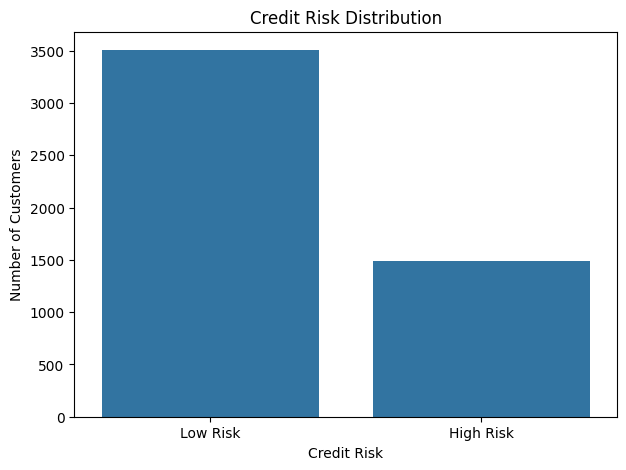

In [16]:
plt.figure(figsize=(7, 5))

sns.countplot(
    x="credit_risk",
    data=df
)

plt.title("Credit Risk Distribution")
plt.xlabel("Credit Risk")
plt.ylabel("Number of Customers")

plt.xticks(
    [0, 1],
    ["Low Risk", "High Risk"]
)

plt.show()

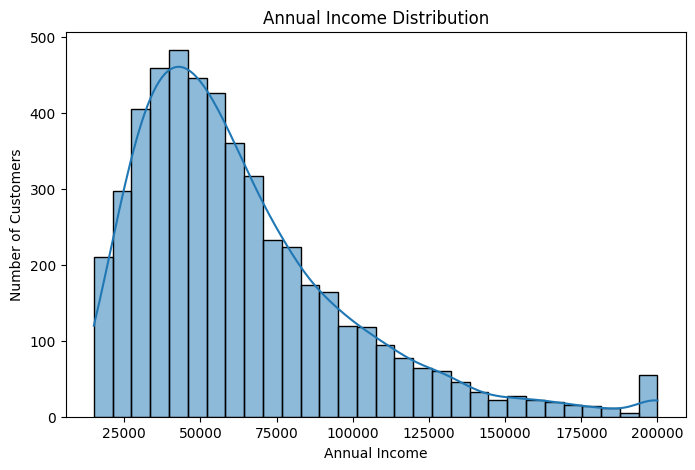

In [17]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["annual_income"],
    bins=30,
    kde=True
)

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income")
plt.ylabel("Number of Customers")

plt.show()

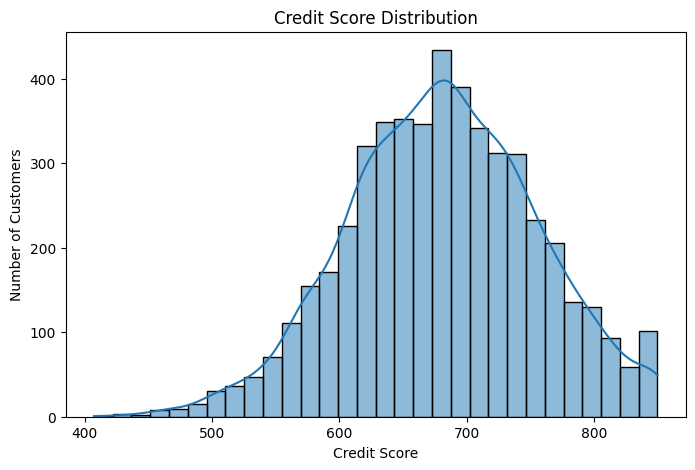

In [18]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["credit_score"],
    bins=30,
    kde=True
)

plt.title("Credit Score Distribution")
plt.xlabel("Credit Score")
plt.ylabel("Number of Customers")

plt.show()

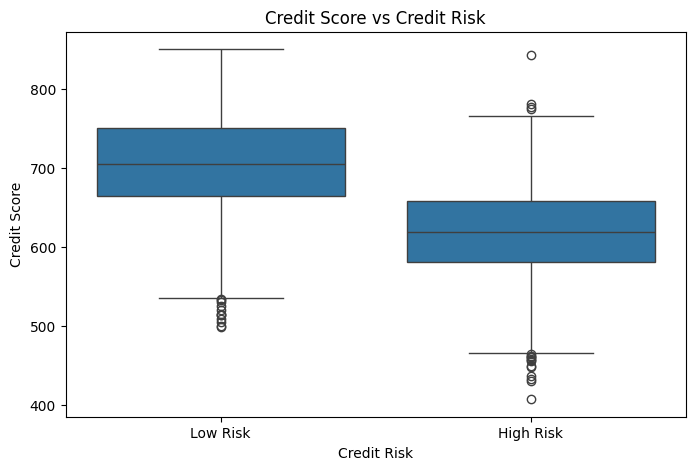

In [19]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="credit_risk",
    y="credit_score",
    data=df
)

plt.title("Credit Score vs Credit Risk")
plt.xlabel("Credit Risk")
plt.ylabel("Credit Score")

plt.xticks(
    [0, 1],
    ["Low Risk", "High Risk"]
)

plt.show()

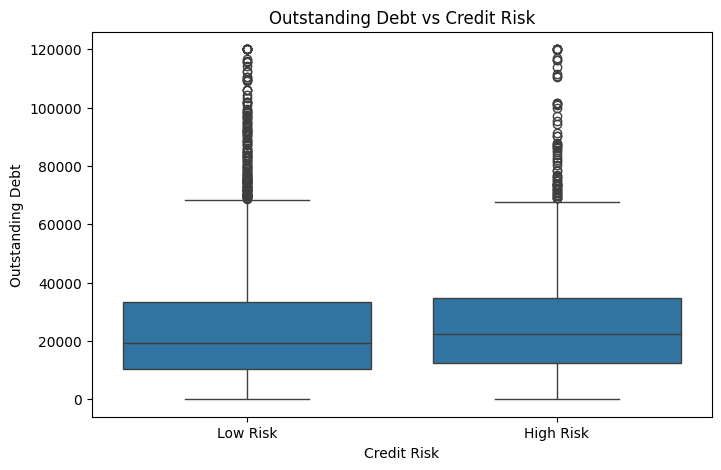

In [20]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="credit_risk",
    y="total_outstanding_debt",
    data=df
)

plt.title("Outstanding Debt vs Credit Risk")
plt.xlabel("Credit Risk")
plt.ylabel("Outstanding Debt")

plt.xticks(
    [0, 1],
    ["Low Risk", "High Risk"]
)

plt.show()

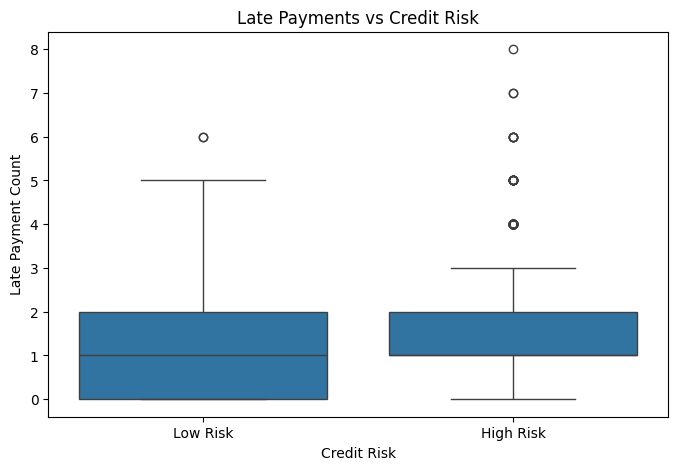

In [21]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="credit_risk",
    y="late_payment_count",
    data=df
)

plt.title("Late Payments vs Credit Risk")
plt.xlabel("Credit Risk")
plt.ylabel("Late Payment Count")

plt.xticks(
    [0, 1],
    ["Low Risk", "High Risk"]
)

plt.show()

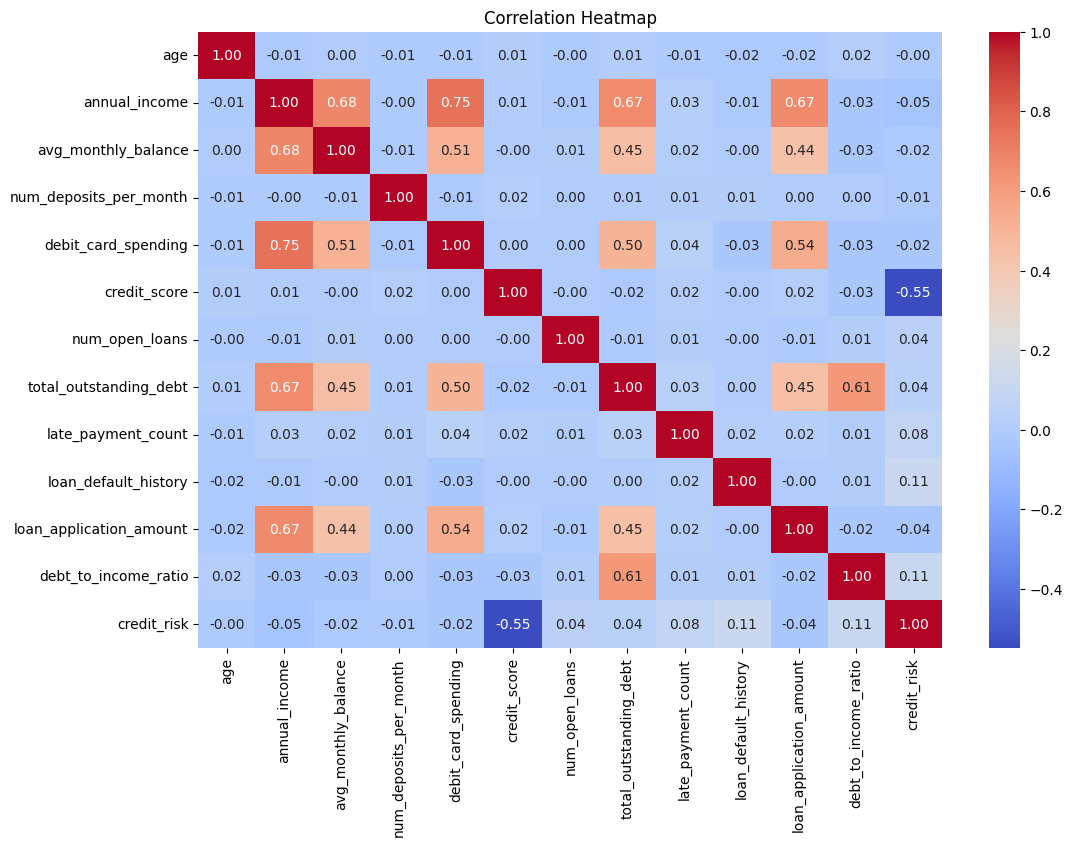

In [22]:
plt.figure(figsize=(12, 8))

correlation = df.select_dtypes(
    include=np.number
).corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [23]:
X = df.drop("credit_risk", axis=1)

y = df["credit_risk"]

In [24]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5000, 14)
y shape: (5000,)


In [25]:
X.select_dtypes(include="object").columns

Index(['employment_status', 'loan_repayment_history'], dtype='object')

In [26]:
label_encoders = {}

for column in X.select_dtypes(include="object").columns:

    encoder = LabelEncoder()

    X[column] = encoder.fit_transform(X[column])

    label_encoders[column] = encoder

In [27]:
X.head()

,age,employment_status,annual_income,avg_monthly_balance,num_deposits_per_month,debit_card_spending,credit_score,num_open_loans,total_outstanding_debt,late_payment_count,loan_default_history,loan_application_amount,loan_repayment_history,debt_to_income_ratio
0,59,0,86331.0,4607.0,1,2092,685.0,2,41960.0,1,0,21050,3,0.486
1,49,0,49394.0,2072.0,5,2169,741.0,2,21647.0,2,0,17330,2,0.438
2,35,0,64768.0,4341.0,1,3102,550.0,1,20315.0,1,0,14284,1,0.314
3,63,0,137596.0,8105.0,3,5904,686.0,2,53287.0,0,0,28094,2,0.387
4,28,0,17101.0,296.0,1,306,675.0,2,9797.0,0,0,5919,0,0.573


In [28]:
print(y.value_counts())

credit_risk
0    3507
1    1493
Name: count, dtype: int64


In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [30]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (4000, 14)
Testing data: (1000, 14)


In [31]:
logistic_model = LogisticRegression(
    max_iter=1000
)

logistic_model.fit(
    X_train,
    y_train
)

LogisticRegression(max_iter=1000)

In [32]:
y_pred_lr = logistic_model.predict(X_test)

In [33]:
decision_tree = DecisionTreeClassifier(
    random_state=42
)

decision_tree.fit(
    X_train,
    y_train
)

DecisionTreeClassifier(random_state=42)

In [34]:
y_pred_dt = decision_tree.predict(X_test)

In [35]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(
    X_train,
    y_train
)

RandomForestClassifier(random_state=42)

In [36]:
y_pred_rf = random_forest.predict(X_test)

In [37]:
def evaluate_model(model_name, model, X_test, y_test):

    predictions = model.predict(X_test)

    probabilities = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        probabilities
    )

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    }

In [38]:
results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        logistic_model,
        X_test,
        y_test
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        decision_tree,
        X_test,
        y_test
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        random_forest,
        X_test,
        y_test
    )
)

In [39]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.722,0.617978,0.183946,0.283505,0.731917
1,Decision Tree,0.728,0.543974,0.558528,0.551155,0.679407
2,Random Forest,0.803,0.709016,0.578595,0.637201,0.844859


In [40]:
results_df.round(3)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.722,0.618,0.184,0.284,0.732
1,Decision Tree,0.728,0.544,0.559,0.551,0.679
2,Random Forest,0.803,0.709,0.579,0.637,0.845


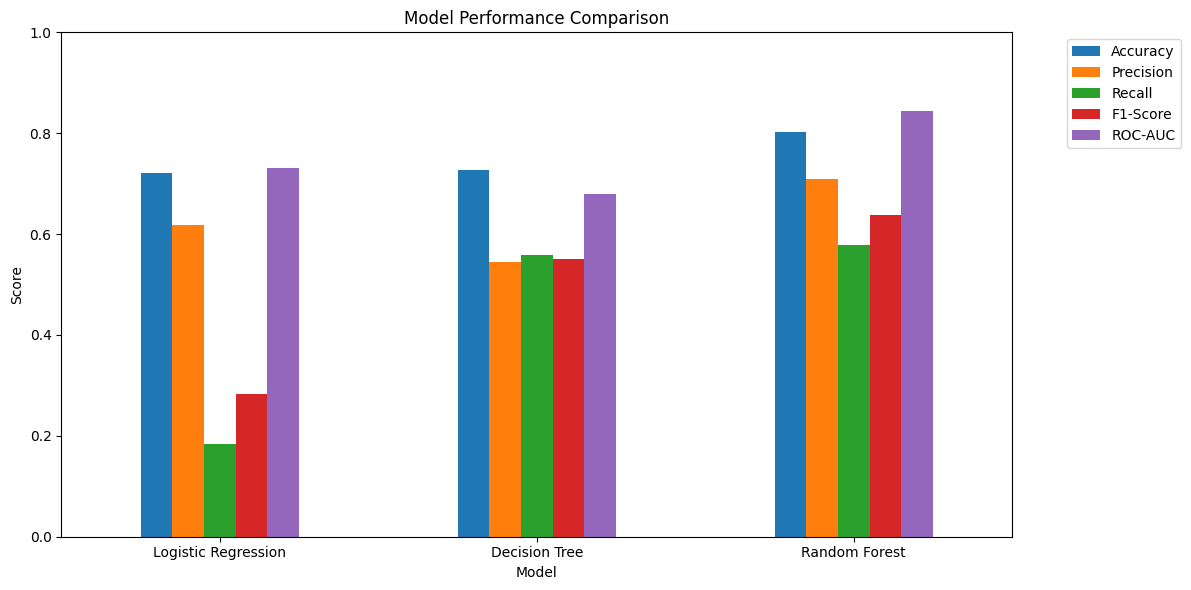

In [41]:
results_plot = results_df.set_index("Model")

results_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

In [42]:
best_model_name = results_df.loc[
    results_df["F1-Score"].idxmax(),
    "Model"
]

print("Best Model:", best_model_name)

Best Model: Random Forest


In [43]:
if best_model_name == "Logistic Regression":

    best_model = logistic_model

elif best_model_name == "Decision Tree":

    best_model = decision_tree

else:

    best_model = random_forest

In [44]:
y_pred_best = best_model.predict(X_test)

print(
    classification_report(
        y_test,
        y_pred_best,
        target_names=[
            "Low Risk",
            "High Risk"
        ]
    )
)

              precision    recall  f1-score   support

    Low Risk       0.83      0.90      0.86       701
   High Risk       0.71      0.58      0.64       299

    accuracy                           0.80      1000
   macro avg       0.77      0.74      0.75      1000
weighted avg       0.80      0.80      0.80      1000



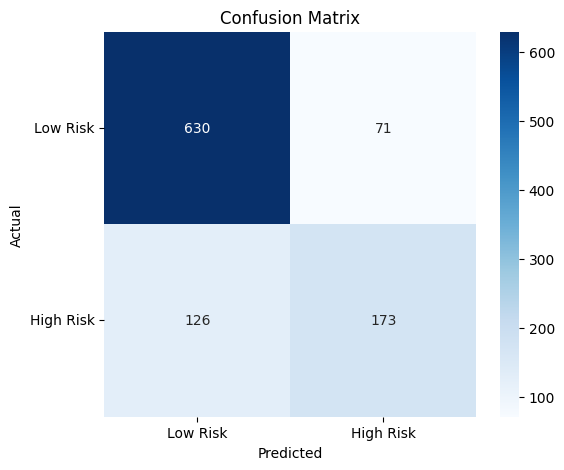

In [45]:
cm = confusion_matrix(
    y_test,
    y_pred_best
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.xticks(
    [0.5, 1.5],
    ["Low Risk", "High Risk"]
)

plt.yticks(
    [0.5, 1.5],
    ["Low Risk", "High Risk"],
    rotation=0
)

plt.show()

In [46]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
6,credit_score,0.366236
13,debt_to_income_ratio,0.075342
2,annual_income,0.070143
5,debit_card_spending,0.068464
8,total_outstanding_debt,0.067349
11,loan_application_amount,0.065527
3,avg_monthly_balance,0.062912
0,age,0.058995
4,num_deposits_per_month,0.044780
7,num_open_loans,0.033220


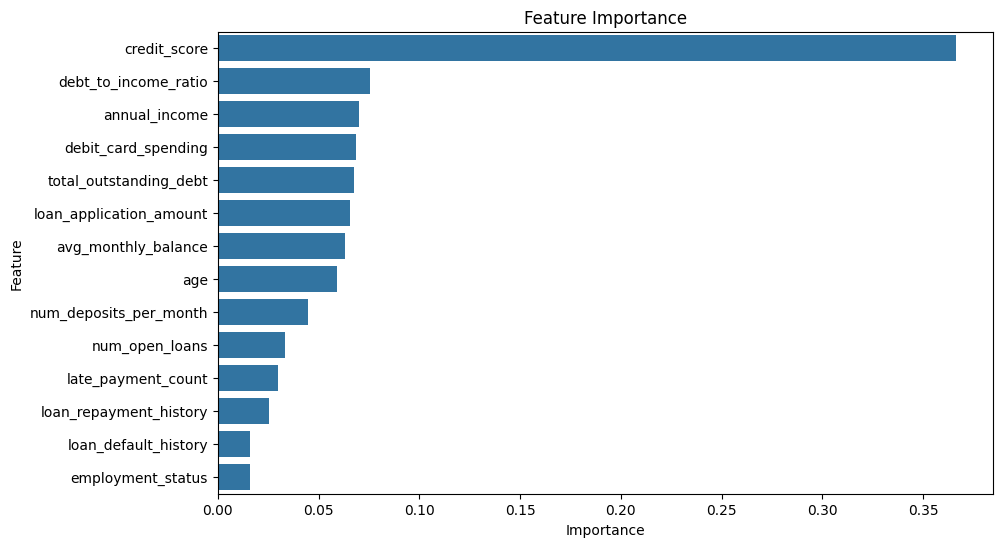

In [47]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title("Feature Importance")

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.show()

In [48]:
sample_customer = X_test.iloc[[0]]

sample_prediction = best_model.predict(
    sample_customer
)

print("Encoded prediction:", sample_prediction[0])

Encoded prediction: 0


In [49]:
if sample_prediction[0] == 0:
    print("Credit Risk: Low Risk")
else:
    print("Credit Risk: High Risk")

Credit Risk: Low Risk


In [50]:
!pip install gradio -q

In [51]:
import gradio as gr

In [52]:
def predict_credit_risk(
    age,
    employment_status,
    annual_income,
    avg_monthly_balance,
    num_deposits_per_month,
    debit_card_spending,
    credit_score,
    num_open_loans,
    total_outstanding_debt,
    late_payment_count,
    loan_default_history,
    loan_application_amount,
    loan_repayment_history
):

    # Calculate debt-to-income ratio
    debt_to_income_ratio = (
        total_outstanding_debt / annual_income
        if annual_income > 0
        else 0
    )

    # Encode categorical values using the encoders
    employment_encoded = label_encoders[
        "employment_status"
    ].transform([employment_status])[0]

    repayment_encoded = label_encoders[
        "loan_repayment_history"
    ].transform([loan_repayment_history])[0]

    # Create customer data
    customer_data = pd.DataFrame({
        "age": [age],
        "employment_status": [employment_encoded],
        "annual_income": [annual_income],
        "avg_monthly_balance": [avg_monthly_balance],
        "num_deposits_per_month": [num_deposits_per_month],
        "debit_card_spending": [debit_card_spending],
        "credit_score": [credit_score],
        "num_open_loans": [num_open_loans],
        "total_outstanding_debt": [total_outstanding_debt],
        "late_payment_count": [late_payment_count],
        "loan_default_history": [loan_default_history],
        "loan_application_amount": [loan_application_amount],
        "loan_repayment_history": [repayment_encoded],
        "debt_to_income_ratio": [debt_to_income_ratio]
    })

    # Make prediction
    prediction = best_model.predict(
        customer_data
    )[0]

    # Probability
    probability = best_model.predict_proba(
        customer_data
    )[0][prediction]

    if prediction == 0:

        result = "🟢 Low Credit Risk"

    else:

        result = "🔴 High Credit Risk"

    return (
        f"{result}\n\n"
        f"Prediction confidence: {probability:.2%}"
    )

In [53]:
demo = gr.Interface(

    fn=predict_credit_risk,

    inputs=[

        gr.Number(
            label="Age",
            value=30
        ),

        gr.Dropdown(
            choices=[
                "Employed",
                "Self-Employed",
                "Unemployed"
            ],
            label="Employment Status",
            value="Employed"
        ),

        gr.Number(
            label="Annual Income",
            value=50000
        ),

        gr.Number(
            label="Average Monthly Balance",
            value=5000
        ),

        gr.Number(
            label="Deposits Per Month",
            value=5
        ),

        gr.Number(
            label="Debit Card Spending",
            value=2000
        ),

        gr.Number(
            label="Credit Score",
            value=680
        ),

        gr.Number(
            label="Number of Open Loans",
            value=2
        ),

        gr.Number(
            label="Total Outstanding Debt",
            value=20000
        ),

        gr.Number(
            label="Late Payment Count",
            value=1
        ),

        gr.Radio(
            choices=[0, 1],
            label="Previous Loan Default",
            value=0
        ),

        gr.Number(
            label="Loan Application Amount",
            value=10000
        ),

        gr.Dropdown(
            choices=[
                "Excellent",
                "Good",
                "Average",
                "Poor"
            ],
            label="Loan Repayment History",
            value="Good"
        )
    ],

    outputs=gr.Textbox(
        label="Credit Risk Prediction"
    ),

    title="💳 Credit Scoring Model",

    description=(
        "Enter customer financial information "
        "to predict credit risk."
    )
)

In [54]:
demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5bd3f0c6db4e32c210.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# Conclusion

In this project, a Credit Scoring Model was developed using customer financial and credit-history data.

Three classification algorithms were trained:

1. Logistic Regression
2. Decision Tree
3. Random Forest

The models were evaluated using:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

The best-performing model was selected based on its F1-Score.

The final model was also integrated into a basic Gradio interface, allowing users to enter financial information and receive a credit-risk prediction.